In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [3]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [4]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], add_soap=True)
df = mp.load()

2026-04-22 15:24:33.824 | INFO     | src.datasets:load:1355 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-22 15:24:34.803 | INFO     | src.datasets:_add_descriptors:1719 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-22 15:24:34.804 | INFO     | src.datasets:_add_descriptors:1723 - Extracting unique elements from formulas...
2026-04-22 15:24:48.527 | INFO     | src.datasets:_add_descriptors:1732 - Found 86 unique elements.
2026-04-22 15:24:48.537 | INFO     | src.datasets:_add_descriptors:1777 - Computing SOAP chunk 0 (0 to 1000)...
2026-04-22 15:24:50.129 | INFO     | src.datasets:_add_descriptors:1777 - Computing SOAP chunk 1 (1000 to 2000)...
2026-04-22 15:24:51.940 | INFO     | src.datasets:_add_descriptors:1777 - Computing SOAP chunk 2 (2000 to 3000)...
2026-04-22 15:24:53.733 | INFO     | src.datasets:_add_descriptors:1777 - Computing SOAP chunk 3 (3000 to 4000)...
20

In [5]:
print(np.array(df["soap_embedding"].to_list()[0]).shape)

(252,)


In [5]:
dist_type = "soap_kernel"
dist_matrix = mp.get_distance_matrix(
    descriptor="soap",
    dist_type=dist_type,
    force_calculate=True,
    pca_components=4,
)

2026-04-22 15:25:01.597 | INFO     | src.datasets:get_distance_matrix:1988 - Applying PCA to reduce 'soap' to 4 dimensions.
2026-04-22 15:25:01.615 | INFO     | src.datasets:get_distance_matrix:1994 - PCA kept 99.57% of the variance for 'soap'.
2026-04-22 15:25:01.616 | INFO     | src.datasets:get_distance_matrix:1996 - PCA reduced 'soap' dimensions from 252 to 4
2026-04-22 15:25:01.629 | INFO     | src.datasets:get_distance_matrix:2014 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-22 15:25:01.909 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/Materials Project/dist_soap_soap_kernel_pca4.npy


# Hierarchical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_47717/24061070.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2], dtype=int32), array([3156, 1844]))


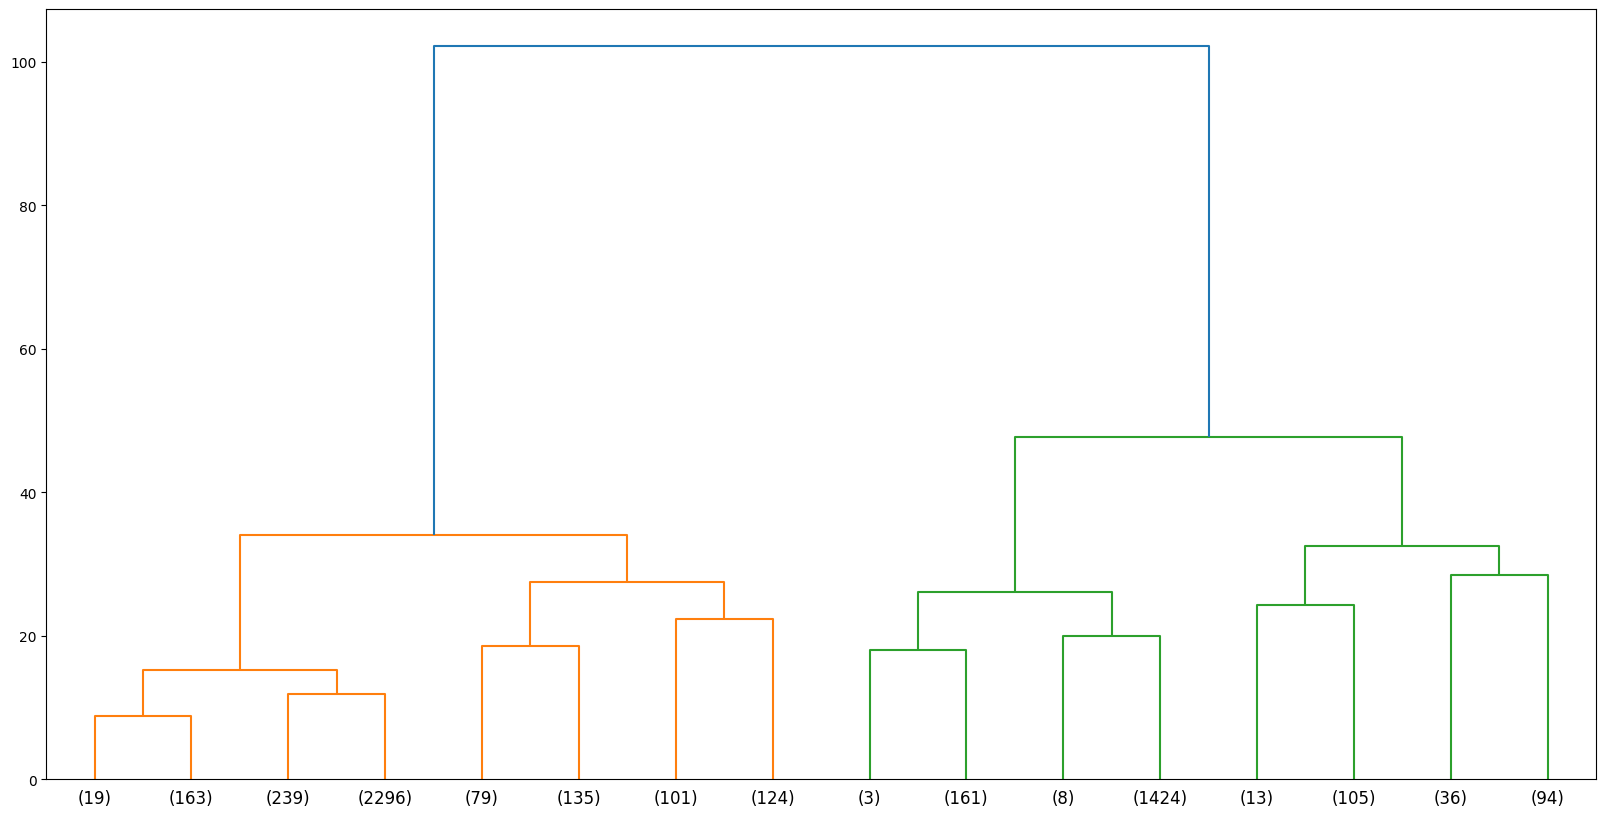

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=3, truncate_mode='level')
labels_hier = fcluster(link, t=80, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [12]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (2, 31)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_anonymized_formula ┆ top

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-21 09:30:44.690 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_hierarchical_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [9]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [24]:
model_km = KMedoids(n_clusters=4, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2, 3], dtype=uint64), array([ 562, 3001,  295, 1142]))


In [26]:
d = average_numeric_by_cluster(df, "labels_km")

shape: (4, 32)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_

In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [24]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-21 09:32:36.323 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_kmedoids_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

# Spectral

In [25]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

KeyboardInterrupt: 

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN

In [27]:
model_db = DBSCAN(
    eps=0.3,
    min_samples=4,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1]), array([  30, 4965,    5]))


In [28]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-21 09:37:06.554 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [29]:
average_numeric_by_cluster(df, "labels_db")

shape: (3, 33)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anon

labels_db,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,30,1.26,-15.746711,-1.005518,0.39667,7.007539,6.150398,6.841861,9.580807,94.868577,94.66132,84.860065,351.088311,19.766667,0.05238,2.387351,2.646118,1.8,1.466667,73.333333,7,"""Tetragonal""",30.0,25,"""Pm-3m""",6.666667,24,"""ABC2""",10.0,25,"""tI10""",13.333333
0,4965,1.57429,-13.542779,-1.293601,0.50577,6.232223,6.800731,7.239713,9.506849,86.692882,87.251411,88.64918,426.997715,25.775428,0.083935,2.304561,2.577566,1.366566,1.403424,60.60423,7,"""Orthorhombic""",21.490433,174,"""P1""",8.922457,991,"""ABC2""",5.800604,644,"""cF16""",3.222558
1,5,0.488,-22.176113,-0.50146,0.02546,6.011968,5.855352,6.575726,8.429758,80.768057,80.089095,91.138311,300.477952,10.4,0.00765,2.648671,2.873014,1.0,1.0,40.0,3,"""Monoclinic""",40.0,5,"""P-4m2""",20.0,5,"""AB3C4D8""",20.0,5,"""tP4""",20.0


# KMeans on Raw Embeddings

In [ ]:
X_raw = np.array(df["soap_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

NameError: name 'np' is not defined

In [ ]:
create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")